## Demos of stiff ODEs and stability regions of multistep explicit and implicit methods

In [1]:
using Plots; using LaTeXStrings;

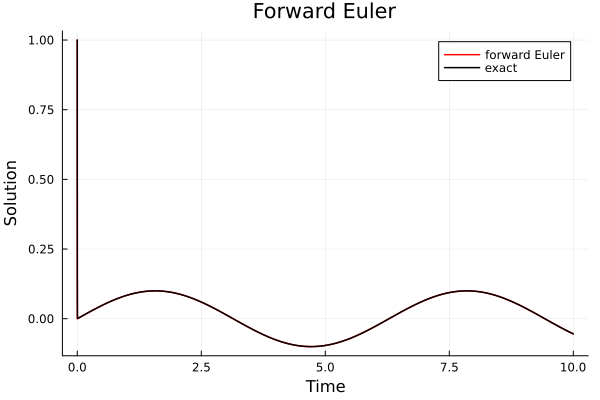

In [13]:
# Parameters
dt = 1e-3
Tmax = 10.0

N = ceil(Int, Tmax / dt)      # number of steps (integer)
lambda = -1000.0

# time vector (N+1 points)
t = range(0.0, stop = Tmax, length = N+1)

# allocate
vf = zeros(Float64, N+1)   # Forward Euler

# Exact solution
ω = 1.0
c2 = 100.0 / (ω^2 + lambda^2)
c1 = 1.0 + ω * c2
ue = c1 .* exp.(lambda .* t) .+ c2 .* (-lambda .* sin.(ω .* t) .- ω .* cos.(ω .* t))

# Forward Euler
vf[1] = 1.0
for n in 1:N
    vf[n+1] = vf[n] + dt * (lambda * vf[n] + 100.0 * sin(t[n]))
end

# Plot Forward Euler
plot(t, vf;
    color = :red,
    label = "forward Euler",
    xlabel = "Time",
    ylabel = "Solution",
    title = "Forward Euler",
    grid = true,
    # legend = false,
    linewidth = 1.5,
    # marker = nothing,
)
# optionally overlay exact
plot!(t, ue, color=:black, lw=1.5, label="exact")


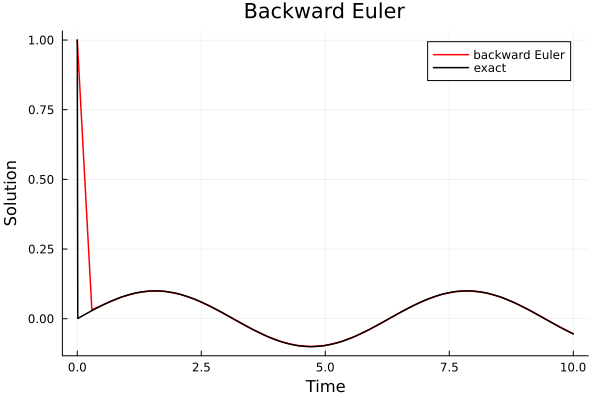

In [20]:
# Parameters
dt = 0.3
Tmax = 10.0

N = ceil(Int, Tmax / dt)      # number of steps (integer)
lambda = -1000.0

# time vector (N+1 points)
t = range(0.0, stop = Tmax, length = N+1)
tfine = range(0.0, stop = Tmax, length = 1000);

# allocate
vb = zeros(Float64, N+1)   # Backward Euler

# Exact solution
ω = 1.0
c2 = 100.0 / (ω^2 + lambda^2)
c1 = 1.0 + ω * c2
ue = c1 .* exp.(lambda .* tfine) .+ c2 .* (-lambda .* sin.(ω .* tfine) .- ω .* cos.(ω .* tfine))


# Backward Euler
vb[1] = 1.0
den_be = 1.0 .- dt * lambda    # scalar but written this way for clarity
for n in 1:N
    # use t[n+1] for the forcing at the new time
    vb[n+1] = (vb[n] + dt * 100.0 * sin(t[n+1])) / den_be
end

# Plot Backward Euler
plot(t, vb;
    color = :red,
    label = "backward Euler",
    xlabel = "Time",
    ylabel = "Solution",
    title = "Backward Euler",
    grid = true,
    # legend = false,
    linewidth = 1.5,
)

# optionally overlay exact
plot!(tfine, ue, color=:black, lw=1.5, label="exact")

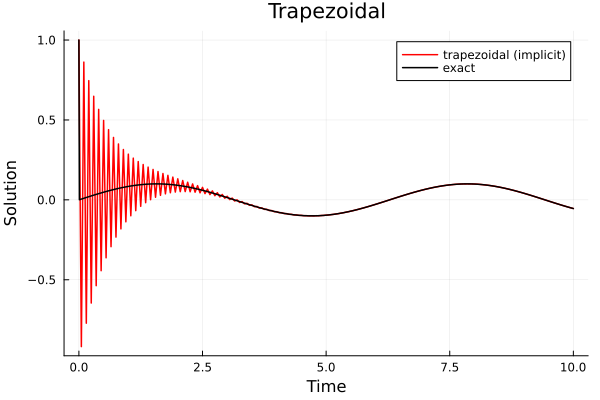

In [23]:
# Parameters
dt = 5e-2
Tmax = 10.0

N = ceil(Int, Tmax / dt)      # number of steps (integer)
lambda = -1000.0

# time vector (N+1 points)
t = range(0.0, stop = Tmax, length = N+1)
tfine = range(0.0, stop = Tmax, length = 1000);

# allocate
vt = zeros(Float64, N+1)   # Trapezoidal

# Exact solution
ω = 1.0
c2 = 100.0 / (ω^2 + lambda^2)
c1 = 1.0 + ω * c2
ue = c1 .* exp.(lambda .* tfine) .+ c2 .* (-lambda .* sin.(ω .* tfine) .- ω .* cos.(ω .* tfine))


# Trapezoidal method (Crank–Nicolson)
vt[1] = 1.0
den_trap = 1.0 .- 0.5 * dt * lambda
for n in 1:N
    vt[n+1] = (vt[n] + 0.5 * dt * lambda * vt[n] + 0.5 * dt * 100.0 * (sin(t[n]) + sin(t[n+1]))) / den_trap
end

# Plot Trapezoidal
plot(t, vt;
    color = :red,
    label = "trapezoidal (implicit)",
    xlabel = "Time",
    ylabel = "Solution",
    title = "Trapezoidal",
    grid = true,
    # legend = false,
    linewidth = 1.5,
)

# optionally overlay exact
plot!(tfine, ue, color=:black, lw=1.5, label="exact")


In [25]:
using DifferentialEquations;

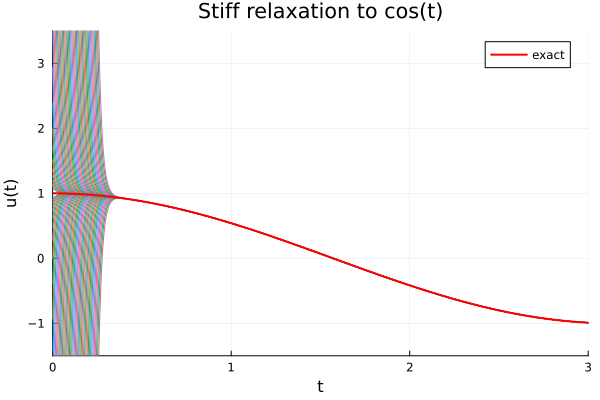

In [32]:
#--- ODE: cos_relax 
function cos_relax!(du, u, p, t)
    du[1] = -50*(u[1] - cos(t)) - sin(t)
end

# prepare plotting
plt = plot(title="Stiff relaxation to cos(t)", xlabel="t", ylabel="u(t)", grid=true)

# offsets
offsets = 10 .^ range(-1, 6, length=50)
ics = vcat(1 .- offsets, 1 .+ offsets)

# solve for each initial condition and plot
for u0 in ics
    prob = ODEProblem(cos_relax!, [u0], (0.0, π))
    sol = solve(prob, Rodas5(),saveat=range(0, π, length=1001))   # stiff solver
    plot!(sol.t, sol[1,:], linewidth=1, label=false)
end

# exact solution u(t)=cos(t)
t_exact = range(0.0, stop=π, length=200)
plot!(t_exact, cos.(t_exact), color=:red, linewidth=2, label="exact")

xlims!(0, 3)
ylims!(-1.5, 3.5)

display(plt)

# General families of linear multistep schemes

![caption](stencils_multistep.png)

# Stability regions for Adams-Bashforth (explicit) schemes of varying order $p$

Which ones are familiar already?

![caption](ab_stab.png)

Stable _inside_ the indicated contours

# Stability regions for Adams-Moulton (explicit) schemes of varying order $p$

Again, which ones are already familiar?

![caption](am_stab.png)

$p=1$: stable outside the circle
$p=2$: stable entire LH plane
$p=3,4$: stable _inside_ the indicated contours

# Stability regions for backwards differentiations formulae (BDFs)

![caption](bd_stab.png)

Interior of each closed curve is the _unstable_ region!